Notebook to test out action parameters in an ad-hoc fashion on the Muller-Brown potential. This notebook is intended to get an intuitive sense for how different constants/actions affect the optimized transition path. For a more rigorous grid search approach, see the mb_tests.py file.

In [1]:
import torch
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

from simpleMB import SimpleMB

import numpy as np
import matplotlib.pyplot as plt

class Args():
    pass

args = Args()
args.device = "cuda"




In [2]:
from tqdm import tqdm
import imageio
from mb_actions import SimpleAction, S2Action, TruncatedAction
from ase import units

potential = SimpleMB(device = "cuda",n_in=2)

x0, xf = potential.initial_point.cuda().detach(), potential.final_point.cuda().detach()
# print(x0.shape, xf.shape)

print(potential.force_func(x0.unsqueeze(0))[0])
print(potential.force_func(xf.unsqueeze(0))[0])

/home/sanjeevr/miniforge3/envs/om-diffusion/lib/python3.12/site-packages/torch/_functorch/deprecated.py:61: UserWarning: We've integrated functorch into PyTorch. As the final step of the integration, functorch.vmap is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use torch.vmap instead; see the PyTorch 2.0 release notes and/or the torch.func migration guide for more details https://pytorch.org/docs/master/func.migrating.html
  warn_deprecated('vmap', 'torch.vmap')


tensor([[ 0.5904, -0.7353]], device='cuda:0')
tensor([[-0.2582,  0.3323]], device='cuda:0')


/home/sanjeevr/miniforge3/envs/om-diffusion/lib/python3.12/site-packages/torch/_functorch/deprecated.py:69: UserWarning: We've integrated functorch into PyTorch. As the final step of the integration, functorch.grad_and_value is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use torch.func.grad_and_value instead; see the PyTorch 2.0 release notes and/or the torch.func migration guide for more details https://pytorch.org/docs/master/func.migrating.html
  warn_deprecated('grad_and_value')


  0%|          | 0/1000 [00:00<?, ?it/s]

/tmp/ipykernel_1663095/1028905282.py:87: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  image = np.frombuffer(fig.canvas.tostring_rgb(), dtype="uint8")
  2%|▏         | 23/1000 [00:00<00:08, 119.32it/s]

OM Action: 121.02637481689453, Path Contribution: 0.504%, Force Contribution: 99.496%


 12%|█▏        | 121/1000 [00:00<00:06, 146.13it/s]

OM Action: 16.55168342590332, Path Contribution: 38.211%, Force Contribution: 61.789%


...

OM Action: 8.38349437713623, Path Contribution: 49.117%, Force Contribution: 50.883%


 92%|█████████▏| 915/1000 [00:06<00:00, 121.26it/s]

OM Action: 8.365558624267578, Path Contribution: 48.992%, Force Contribution: 51.008%


100%|██████████| 1000/1000 [00:07<00:00, 142.53it/s]


Initial action: 121.02637481689453, Final action: 8.37205982208252, Percent improvement: 93.0824501396915%
Initial path norm: 0.6103678941726685, Final path norm: 4.1038007736206055, Percent improvement: -572.348728168797%
Initial force norm: 120.41600799560547, Final force norm: 4.268259048461914, Percent improvement: 96.45540562296527%


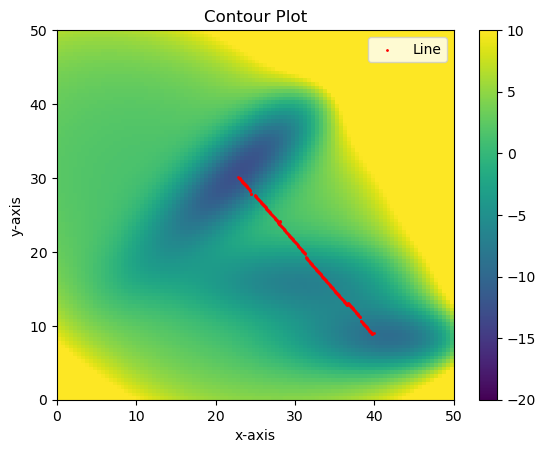

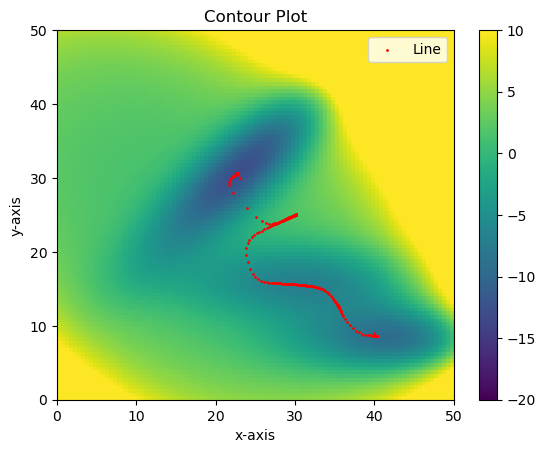

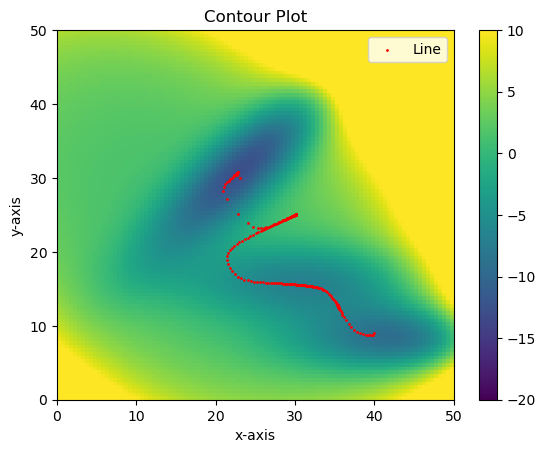

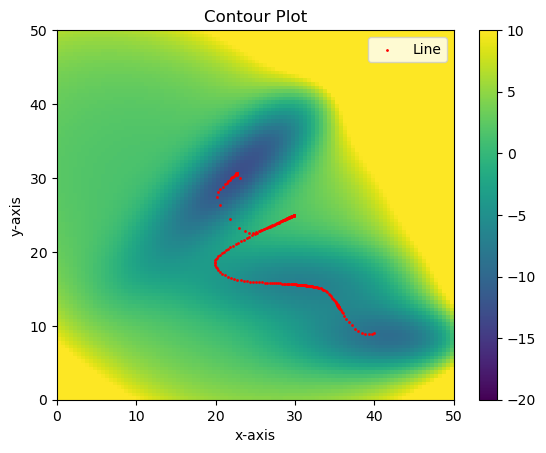

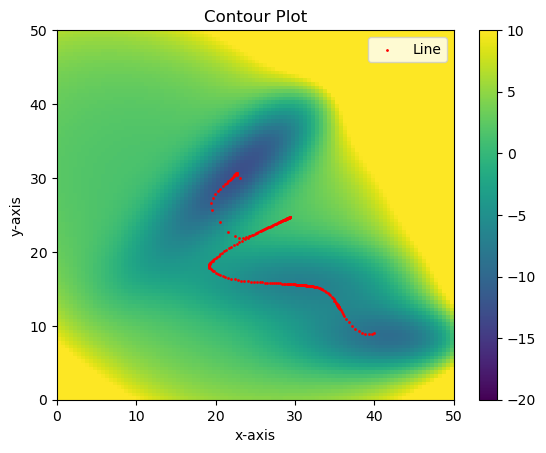

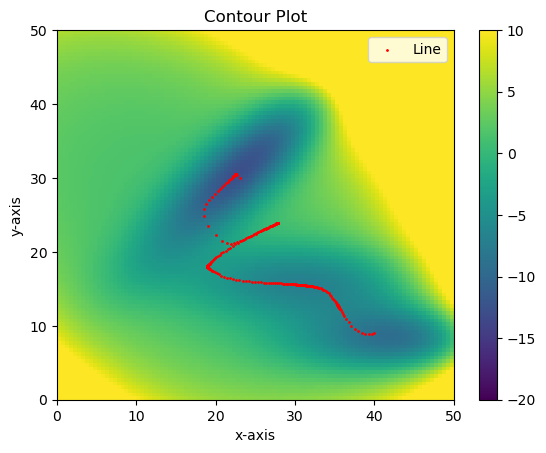

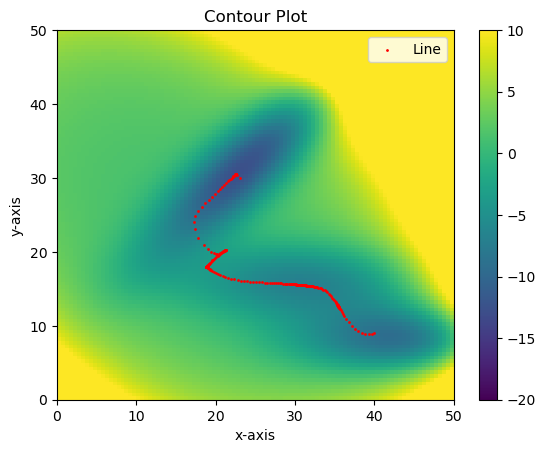

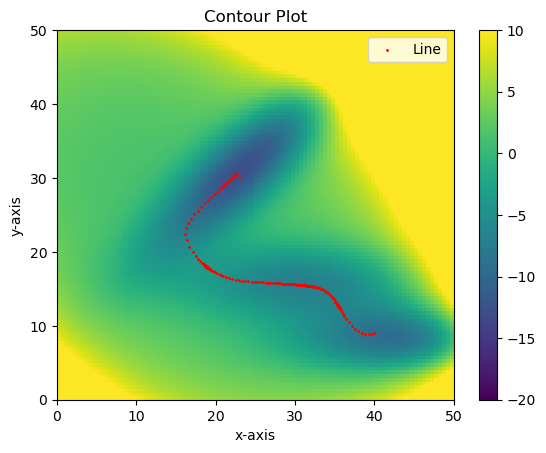

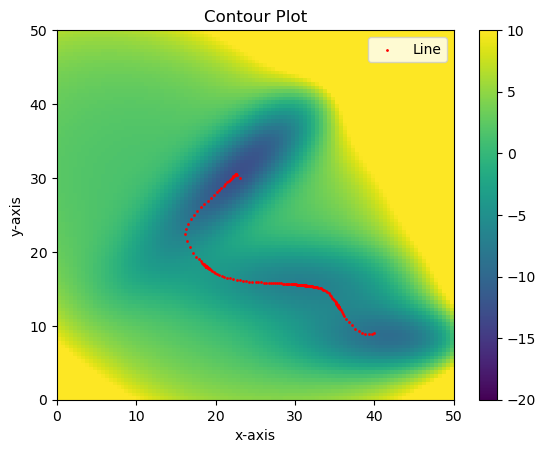

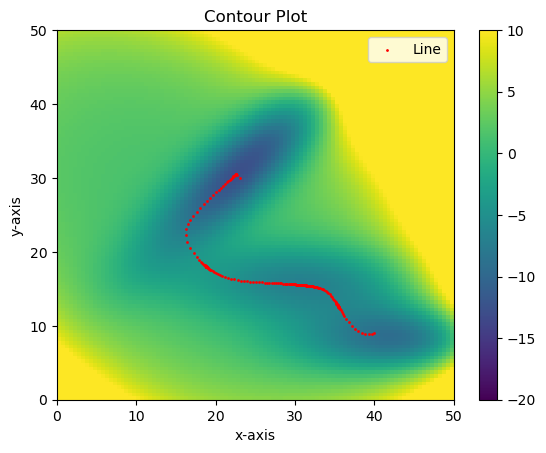

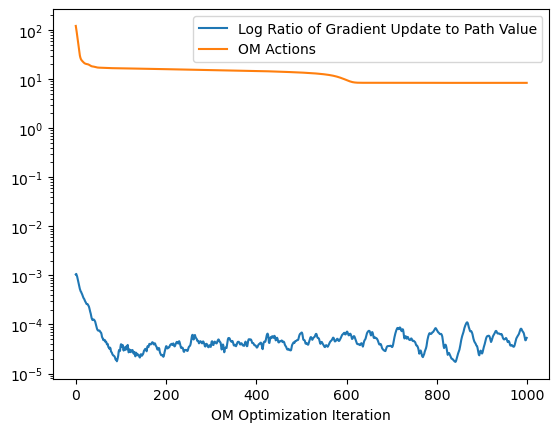

In [6]:


"""Optimization Hyperparameters"""

line_density = 300 # path length
dt = 0.1 # time step to use in action
gamma = torch.tensor(0.1) # gamma value to use in action
D = torch.tensor(0.2) # diffusion coefficient to use in action
#Choose action type
# action_cls = SimpleAction
action_cls = TruncatedAction
force_func = lambda x: potential.force_func(x)[0]
action_func = action_cls(force_func = force_func, laplace_func = potential.laplace, dt = dt, gamma = gamma, D = D)

iterations = 1000 # number of optimization steps
alpha = 2e-1 # learning rate
write_every = 100 # how often to write to gif

line_x = torch.linspace(x0[0], xf[0],line_density)
line_y = torch.linspace(x0[1], xf[1], line_density)
line_points = torch.stack((line_x, line_y), axis=-1).to(args.device)

optimizer = torch.optim.Adam([line_points], lr = alpha)

gif_data = []

min_action = 1e9
pbar = tqdm(range(iterations))
ratios = []
actions = []
path_terms = []
force_terms = []
for i in pbar:
    line_points.requires_grad = True
    first_term, second_term = action_func(line_points)
    action = second_term #first_term + second_term
    # action = action_func(line_points)
    if action < min_action:
        min_action = action
        best_path = line_points.detach().cpu()
    

    total_action = action

    optimizer.zero_grad()

    grads, = torch.autograd.grad(total_action, line_points)

    
    with torch.no_grad():
        grads[0,:], grads[-1,:] = torch.zeros(2).to(args.device), torch.zeros(2).to(args.device)
        line_points.grad = grads
        optimizer.step()

        grads = grads.cpu()

        #Calculate the alternative action
        # s_action = simple_action(line_points)

        
    grad_ratio = alpha * torch.norm(grads, dim = 1) / torch.norm(line_points.cpu(), dim = 1)
    # pbar.set_description(f"Grad update ratio: {grad_ratio.mean().item()}")
    ratios.append(grad_ratio.mean().item())
    actions.append(total_action.item())
    path_terms.append(first_term.item())
    force_terms.append(second_term.item())
    if i % write_every == 0:
        
        print(f"OM Action: {action.item()}, Path Contribution: {round(first_term.item() / action.item() * 100, 3)}%, Force Contribution: {round(second_term.item() / action.item() * 100, 3)}%")
        draw_points = line_points.detach().cpu()
        # print(f"Total action for the step {i} is {(action).cpu().detach().numpy()}")
        num_points = 100
        x_values = torch.linspace(potential.Lx, potential.Hx , num_points)
        y_values = torch.linspace(potential.Ly, potential.Hy, num_points)

        x, y = torch.meshgrid(x_values.to(args.device), y_values.to(args.device), indexing = 'xy')
        z = potential.U_split(x, y).cpu()

        fig, ax = plt.subplots()
        colorbar = ax.imshow(z, extent=(x_values.min(), x_values.max(), y_values.min(), y_values.max()), vmin=potential.U_min, vmax=potential.U_max, origin='lower', cmap='viridis', aspect='auto')
        ax.set(xlabel="x-axis", ylabel="y-axis", title="Contour Plot")
        plt.colorbar(colorbar)

        scatter_plot = ax.scatter(draw_points[:,0], draw_points[:,1], s=1, c='red', label='Line')
        # quiver_plot = ax.quiver(draw_points[:,0], draw_points[:,1], -grads[:,0], -grads[:,1], scale_units='xy', angles='xy', color='blue', alpha=0.7)
        ax.legend()

        fig.canvas.draw()
        image = np.frombuffer(fig.canvas.tostring_rgb(), dtype="uint8")
        image = image.reshape(
            fig.canvas.get_width_height()[::-1] + (3,)
        )
        gif_data.append(image)

action_str = "S2" if action_func == S2Action else "simple"
imageio.mimsave(f'MB_{action_str}_linedensity={line_density}_gamma={round(gamma.item(), 1)}_dt={round(dt, 1)}_D={round(D.item(), 1)}.gif', gif_data, fps=3)

# Print improvement in action
print(
    f"Initial action: {actions[0]}, Final action: {actions[-1]}, Percent improvement: {(actions[0] - actions[-1]) / actions[0] * 100}%"
)
# Print improvement in path term
print(
    f"Initial path norm: {path_terms[0]}, Final path norm: {path_terms[-1]}, Percent improvement: {(path_terms[0] - path_terms[-1]) / path_terms[0] * 100}%"
)
# Print improvement in force term
print(
    f"Initial force norm: {force_terms[0]}, Final force norm: {force_terms[-1]}, Percent improvement: {(force_terms[0] - force_terms[-1]) / force_terms[0] * 100}%"
)

plt.figure()
plt.plot(ratios, label = "Log Ratio of Gradient Update to Path Value")
plt.plot(actions, label = "OM Actions")
plt.yscale('log')
plt.xlabel("OM Optimization Iteration")
plt.legend()


In [9]:
from mb_dataset import MBDataset
from mb_calculator import MullerBrownPotential
from copy import deepcopy


calculator = MullerBrownPotential(device = "cpu")
dataset = MBDataset(save_path = 'data', transition_path_guess= deepcopy(draw_points).numpy(), timestep = 5.0, temperature = 700, n_steps = 1000, n_sims = 1000, gamma = 0.001)
# dataset = MBDataset(save_path = 'data', transition_path_guess=None, timestep = 5.0, temperature = 500, n_steps = 100, n_sims = 50)

# dataset = MBDataset(preload_sim_dir="data/temp=1000_timestep=5.0_friction=0.1")


Running simulations to collect dataest...
Making data


100%|██████████| 1000/1000 [39:25<00:00,  2.37s/it]


489it [00:20, 23.61it/s]


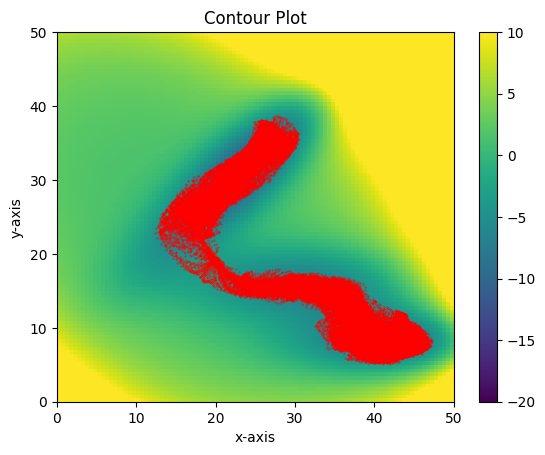

In [11]:
from torch.utils.data import DataLoader
mb_dataloader = DataLoader(dataset, batch_size=2048, shuffle=True)

num_points = 100
x_values = torch.linspace(calculator.Lx, calculator.Hx , num_points)
y_values = torch.linspace(calculator.Ly, calculator.Hy, num_points)

x, y = torch.meshgrid(x_values, y_values, indexing="xy")
z = calculator.U_split(x, y).cpu()

fig, ax = plt.subplots()
colorbar = ax.imshow(z, extent=(x_values.min(), x_values.max(), y_values.min(), y_values.max()), vmin=calculator.U_min, vmax=calculator.U_max, origin='lower', cmap='viridis', aspect='auto')
ax.set(xlabel="x-axis", ylabel="y-axis", title="Contour Plot")
plt.colorbar(colorbar)

# also plot batch from dataloader
for i, batch in tqdm(enumerate(mb_dataloader)):
    ax.scatter(batch[:, 0], batch[:, 1], color='red', s=0.1)

# ax.scatter(draw_points[:,0], draw_points[:,1], s=1, c='blue', label='Line')
    
ax.set_xlim([calculator.Lx, calculator.Hx])
ax.set_ylim([calculator.Ly, calculator.Hy])

plt.show()
plt.close()